Using device: cuda
Loading spectral data...
Model parameters: 582,516
Starting training...


/tmp/ipython-input-10-3818750016.py:122: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 1/50 - Train Loss: 0.162102 - Val Loss: 0.023697 - Time: 1.1s
Epoch 2/50 - Train Loss: 0.081428 - Val Loss: 0.019711 - Time: 0.5s
Epoch 3/50 - Train Loss: 0.036150 - Val Loss: 0.018712 - Time: 0.5s
Epoch 4/50 - Train Loss: 0.021606 - Val Loss: 0.018988 - Time: 0.8s
Epoch 5/50 - Train Loss: 0.020361 - Val Loss: 0.020392 - Time: 0.5s
Epoch 6/50 - Train Loss: 0.021502 - Val Loss: 0.021425 - Time: 0.5s
Epoch 7/50 - Train Loss: 0.022090 - Val Loss: 0.021430 - Time: 0.5s
Epoch 8/50 - Train Loss: 0.021779 - Val Loss: 0.021230 - Time: 0.5s
Epoch 9/50 - Train Loss: 0.020744 - Val Loss: 0.019903 - Time: 0.7s
Epoch 10/50 - Train Loss: 0.019583 - Val Loss: 0.019006 - Time: 0.6s
Epoch 11/50 - Train Loss: 0.018887 - Val Loss: 0.018752 - Time: 0.7s
Epoch 12/50 - Train Loss: 0.018691 - Val Loss: 0.018385 - Time: 0.7s
Epoch 13/50 - Train Loss: 0.018482 - Val Loss: 0.018261 - Time: 0.7s
Epoch 14/50 - Train Loss: 0.018389 - Val Loss: 0.018276 - Time: 0.5s
Epoch 15/50 - Train Loss: 0.018358 - Val Lo

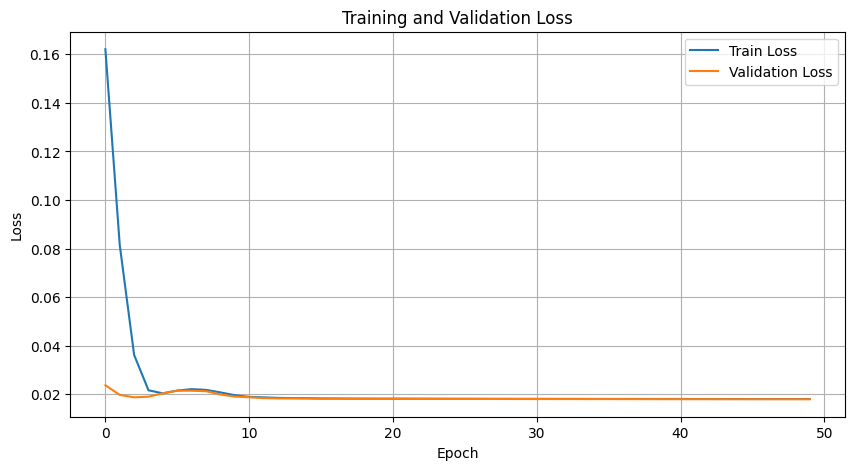

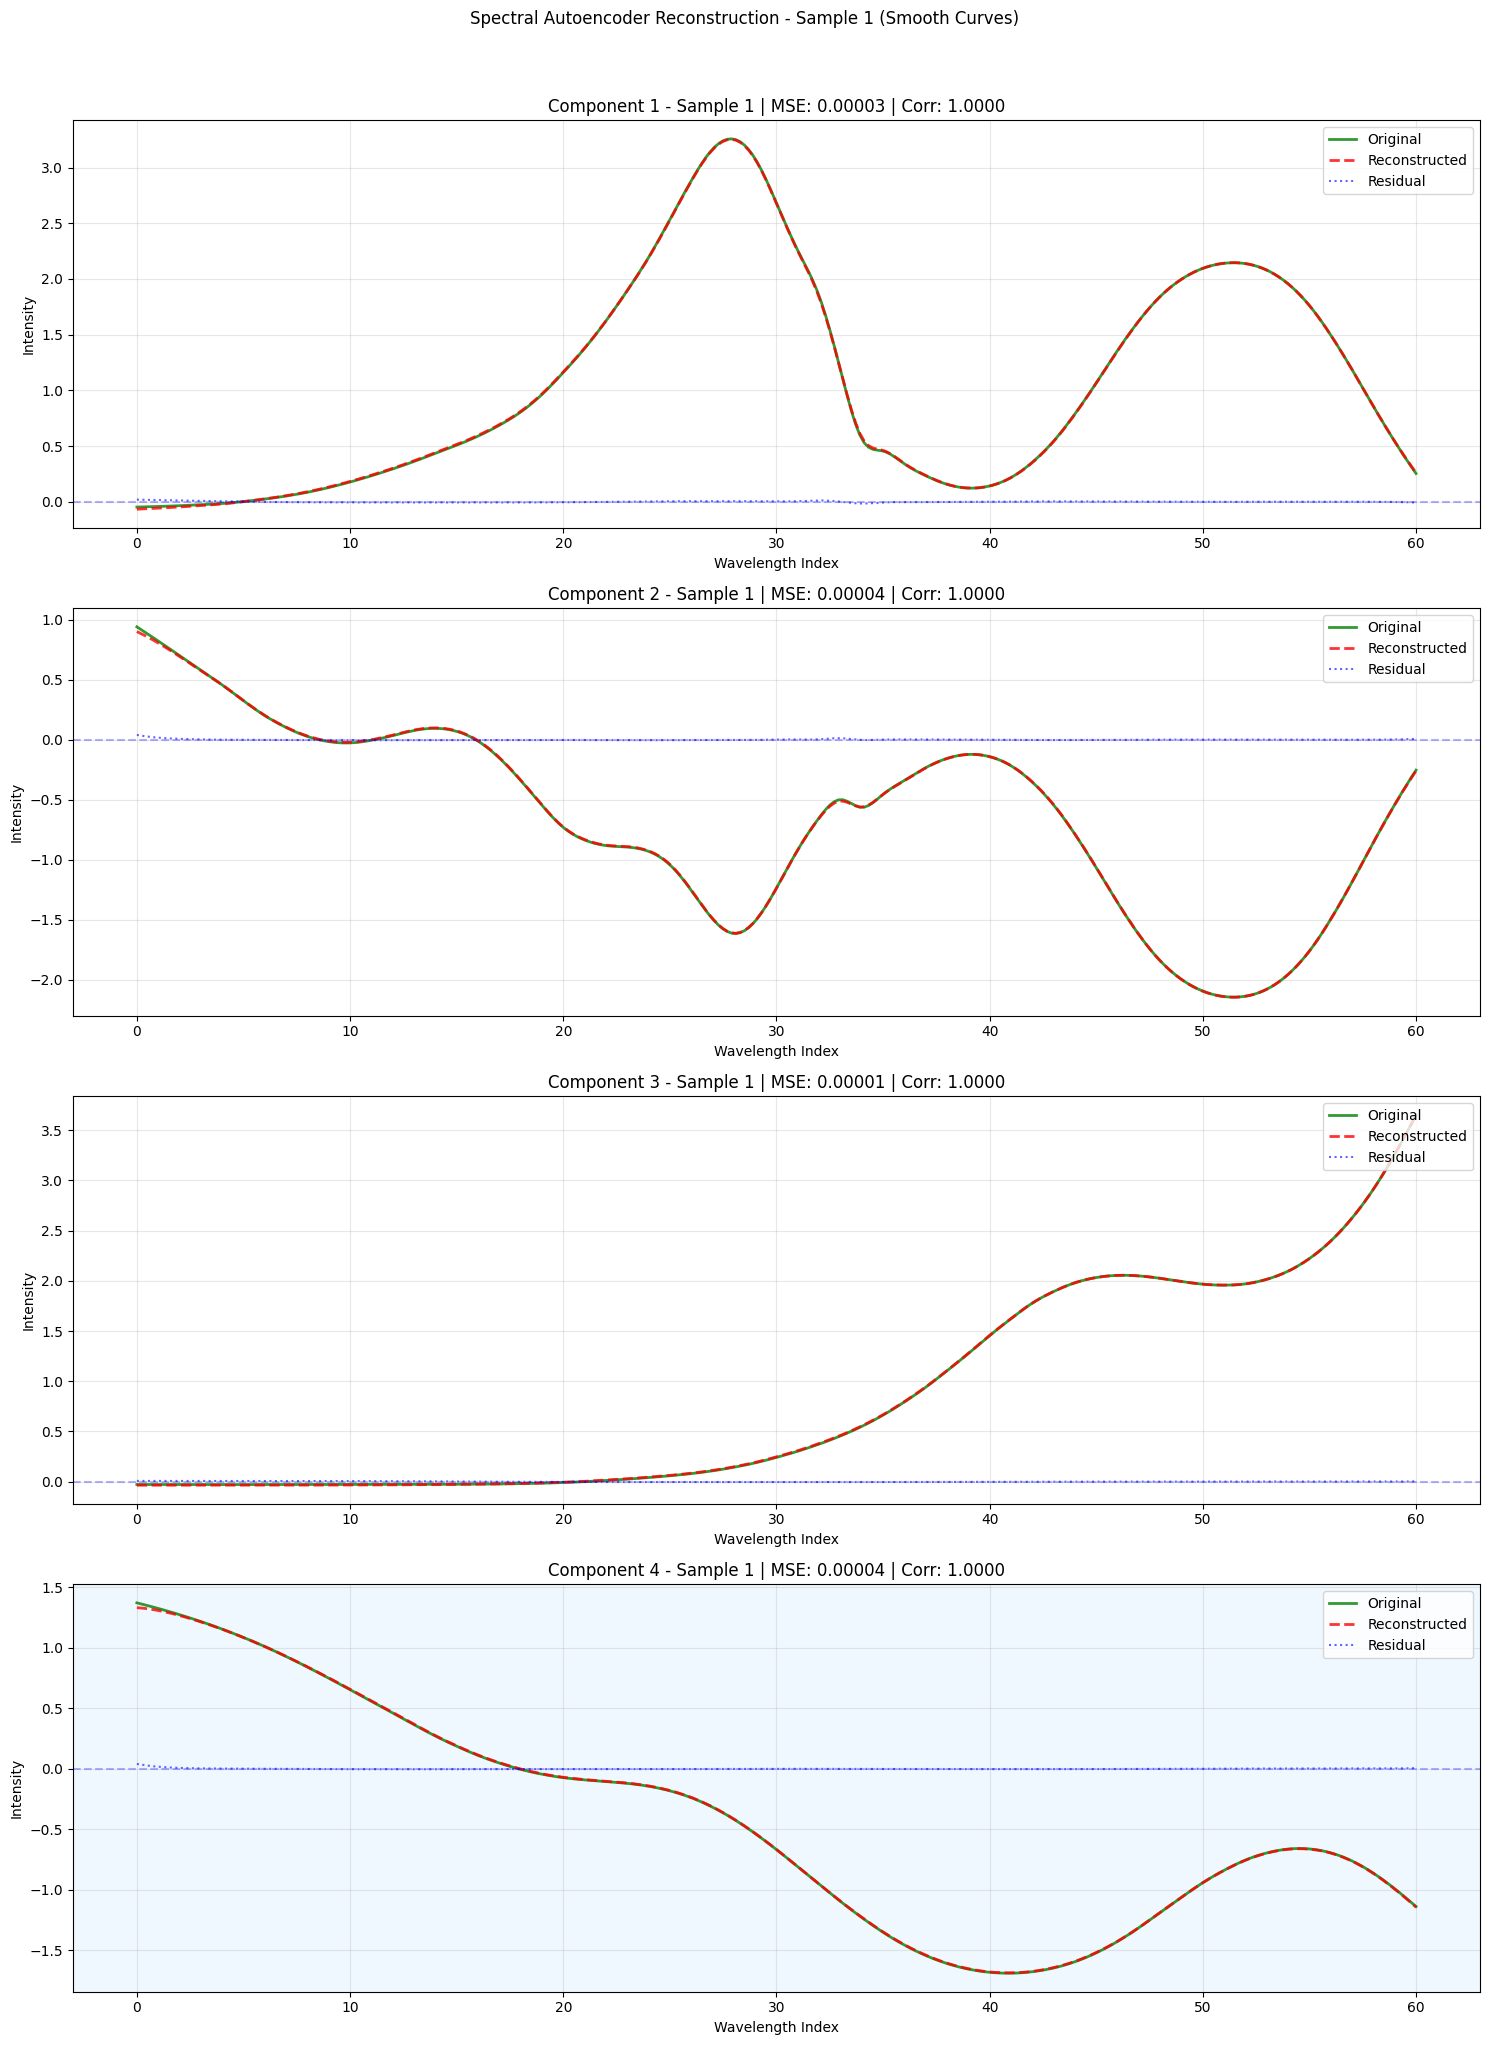

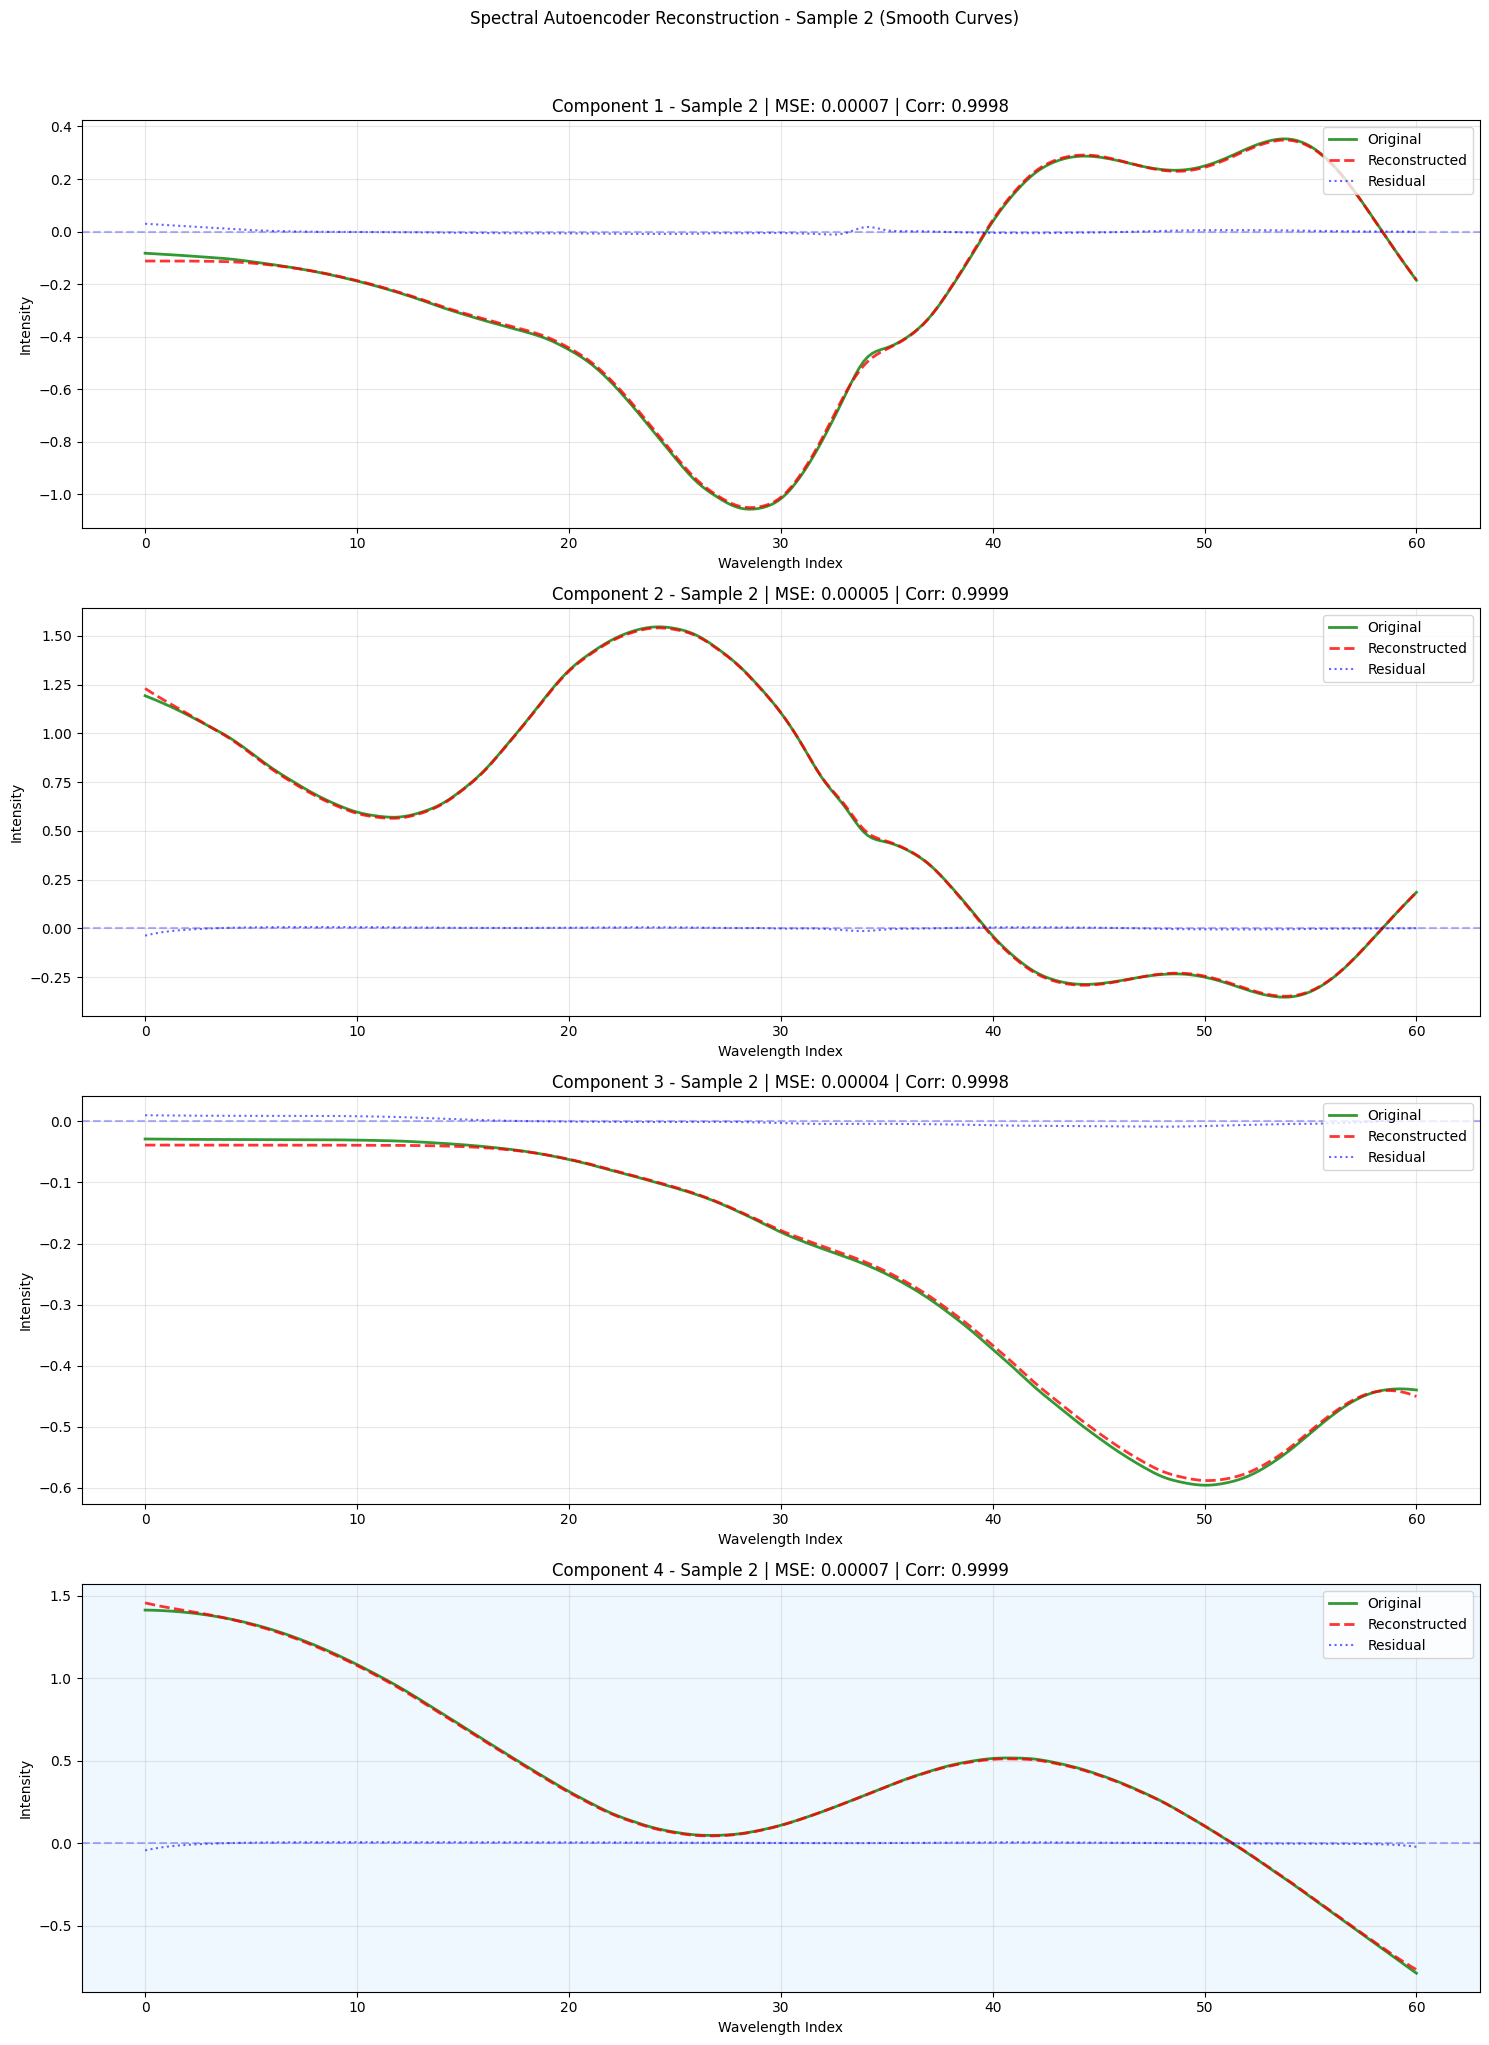

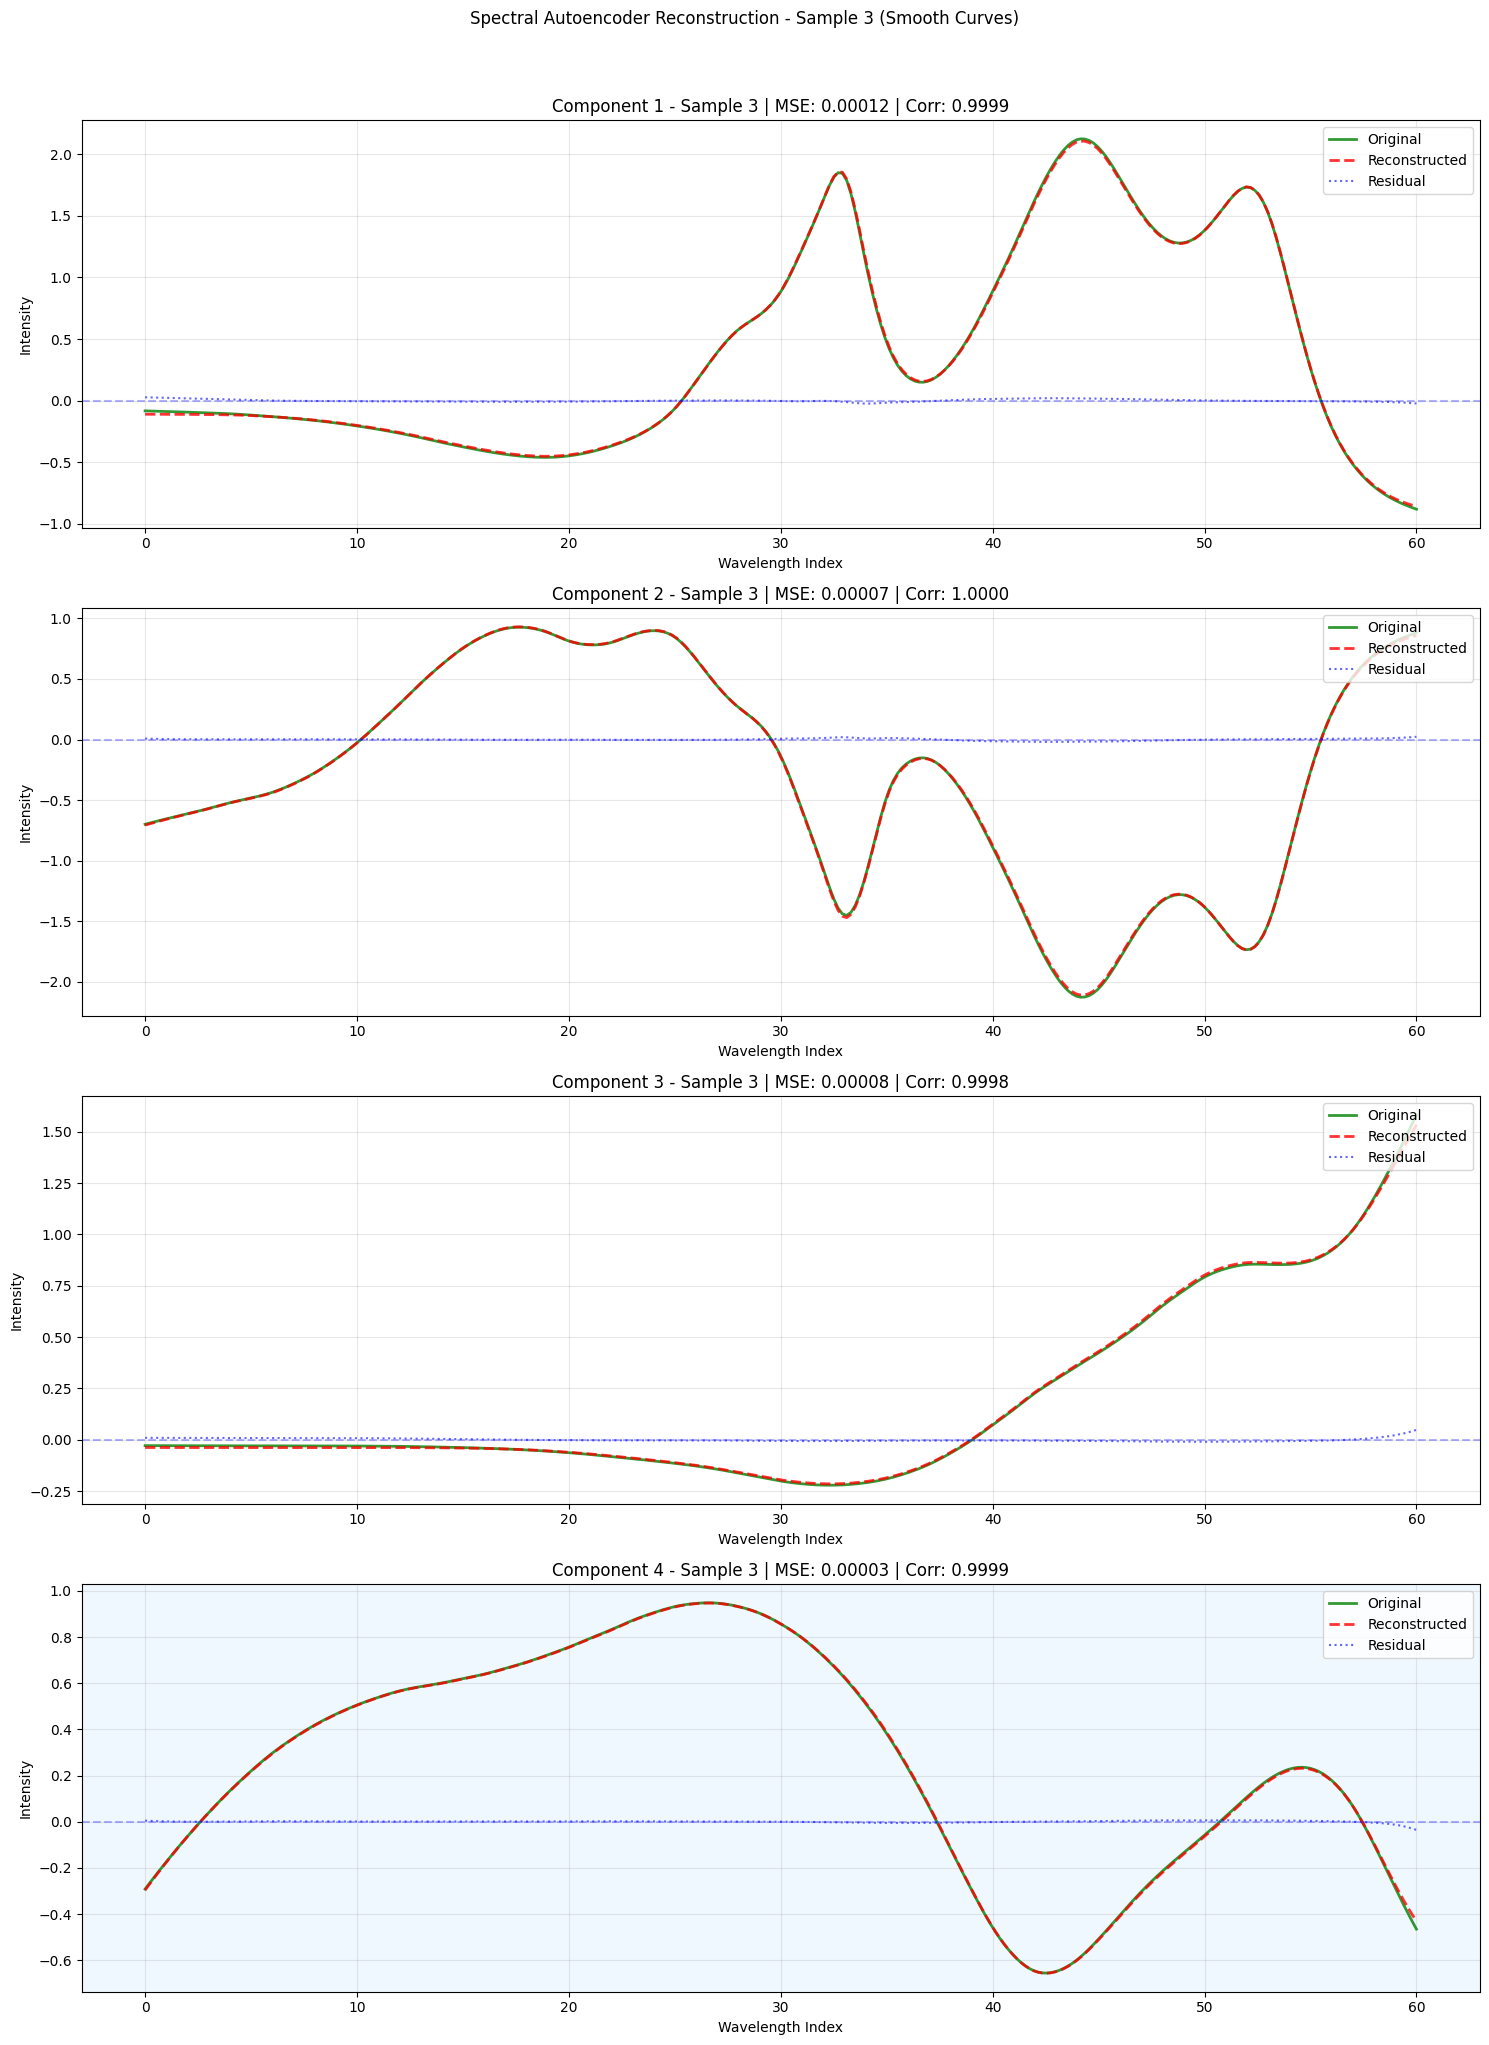

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


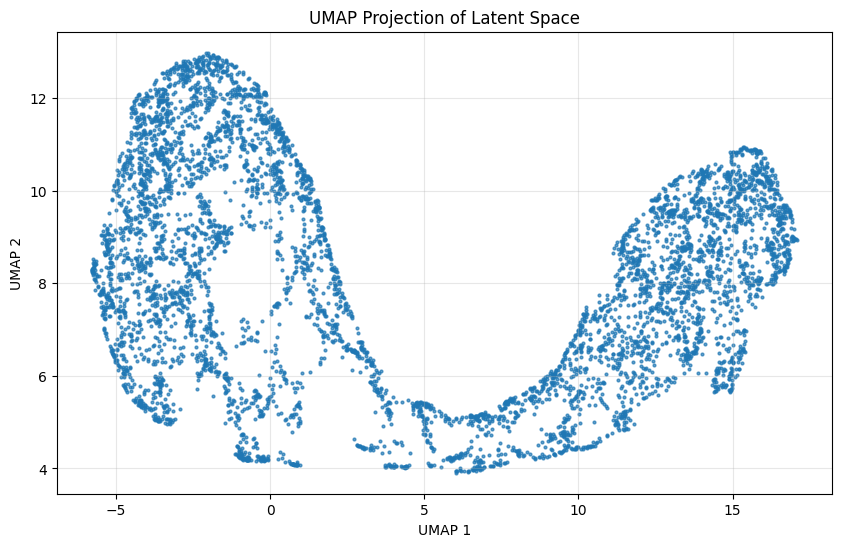

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from time import time
from scipy.interpolate import make_interp_spline
import umap  # You may need: pip install umap-learn

# -- Device setup --
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
use_amp = device.type == 'cuda'   # Use AMP only if CUDA available
scaler_amp = torch.amp.GradScaler("cuda", enabled=use_amp)


# -- Data Loading & Preprocessing --
print("Loading spectral data...")
Y_raw = np.loadtxt(r'/content/drive/MyDrive/Unsupervised/spectra_120k.dat').reshape(-1, 61, 4)[:30000]

# Flatten spectra for scaler
Y_flat = Y_raw.reshape(Y_raw.shape[0], -1)
scaler = StandardScaler()
Y_scaled = scaler.fit_transform(Y_flat)
Y_scaled = Y_scaled.reshape(Y_raw.shape)

# Split train/test (keep on CPU tensors)
Y_train_np, Y_test_np = train_test_split(Y_scaled, test_size=0.2, random_state=42)
Y_train = torch.FloatTensor(Y_train_np)
Y_test = torch.FloatTensor(Y_test_np)

batch_size = 512
train_ds = TensorDataset(Y_train, Y_train)
test_ds = TensorDataset(Y_test, Y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, pin_memory=True)


# -- Model Definition --

class DeepResAutoencoder(nn.Module):
    def __init__(self, input_dim=61*4, latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LayerNorm(512),
            nn.SELU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.SELU(),
            nn.Dropout(0.2),
        )
        self.to_latent = nn.Linear(256, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LayerNorm(256),
            nn.SELU(),
            nn.Dropout(0.2),
            nn.Linear(256, 512),
            nn.LayerNorm(512),
            nn.SELU(),
            nn.Dropout(0.2),
        )
        self.to_output = nn.Linear(512, input_dim)

    def forward(self, x):
        encoded = self.encoder(x)
        latent = self.to_latent(encoded)
        decoded = self.decoder(latent)
        output = self.to_output(decoded)
        # Residual skip connection if shapes match
        if output.shape == x.shape:
            return output + x
        else:
            return output


model = DeepResAutoencoder().to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")


# -- Composite Loss Function --
def composite_loss(y_pred, y_true, alpha=0.5, beta=0.3, gamma=0.2):
    mse = F.mse_loss(y_pred, y_true)
    # cosine similarity averaged over batch
    cosine = 1 - F.cosine_similarity(y_pred, y_true, dim=1).mean()
    # Smoothness regularizer (total variation loss along spectral dimension)
    # y_pred shape: (batch_size, features)
    # Reshape to (batch, 61, 4)
    y_pred_3d = y_pred.view(-1, 61, 4)
    smooth = torch.mean(torch.abs(y_pred_3d[:,1:,:] - y_pred_3d[:,:-1,:]))
    return alpha*mse + beta*cosine + gamma*smooth


# -- Optimizer and Scheduler --
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1e-2,
    steps_per_epoch=len(train_loader),
    epochs=50,
    pct_start=0.3,
    anneal_strategy='cos',
    final_div_factor=10
)


# -- Training & Validation Functions --

def train_epoch(model, loader, optimizer, scaler_amp):
    model.train()
    total_loss = 0
    for X, _ in loader:
        X = X.to(device).view(X.size(0), -1)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=use_amp):
            recon = model(X)
            loss = composite_loss(recon, X)
        scaler_amp.scale(loss).backward()
        scaler_amp.step(optimizer)
        scaler_amp.update()
        total_loss += loss.item()
        scheduler.step()
    return total_loss / len(loader)


def validate_epoch(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X, _ in loader:
            X = X.to(device).view(X.size(0), -1)
            recon = model(X)
            loss = composite_loss(recon, X)
            total_loss += loss.item()
    return total_loss / len(loader)


# -- Training Loop --

epochs = 50
best_val_loss = float('inf')
patience = 10
no_improve = 0
history = {"train_loss": [], "val_loss": []}

print("Starting training...")

for epoch in range(epochs):
    start_time = time()
    train_loss = train_epoch(model, train_loader, optimizer, scaler_amp)
    val_loss = validate_epoch(model, test_loader)
    elapsed = time() - start_time

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.6f} - Val Loss: {val_loss:.6f} - Time: {elapsed:.1f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve = 0
        torch.save(model.state_dict(), 'best_deep_res_autoencoder.pth')
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict(torch.load('best_deep_res_autoencoder.pth'))


# -- Visualization --

def plot_loss_curves(history):
    plt.figure(figsize=(10,5))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_spectral_reconstruction(model, loader, sample_indices=[0, 1, 2]):
    model.eval()
    with torch.no_grad():
        Y_batch, _ = next(iter(loader))
        X = Y_batch.view(Y_batch.size(0), -1).to(device)
        Y_pred = model(X)
        actual = Y_batch.cpu().numpy()
        predicted = Y_pred.cpu().numpy().reshape(-1, 61, 4)

        component_names = ['Component 1', 'Component 2', 'Component 3', 'Component 4']
        x_smooth = np.linspace(0, 60, 300)

        for sample_idx in sample_indices:
            fig, axs = plt.subplots(4, 1, figsize=(15, 20))
            for i in range(4):
                spline_actual = make_interp_spline(np.arange(61), actual[sample_idx, :, i], k=3)
                spline_pred = make_interp_spline(np.arange(61), predicted[sample_idx, :, i], k=3)
                residual = actual[sample_idx, :, i] - predicted[sample_idx, :, i]
                spline_residual = make_interp_spline(np.arange(61), residual, k=3)

                axs[i].plot(x_smooth, spline_actual(x_smooth), 'g-', label='Original', alpha=0.8, linewidth=2)
                axs[i].plot(x_smooth, spline_pred(x_smooth), 'r--', label='Reconstructed', alpha=0.8, linewidth=2)
                axs[i].plot(x_smooth, spline_residual(x_smooth), 'b:', label='Residual', alpha=0.6, linewidth=1.5)
                axs[i].axhline(0, color='b', linestyle='--', alpha=0.3)

                mse = np.mean(residual**2)
                corr = np.corrcoef(actual[sample_idx, :, i], predicted[sample_idx, :, i])[0, 1]

                axs[i].set_title(f"{component_names[i]} - Sample {sample_idx+1} | MSE: {mse:.5f} | Corr: {corr:.4f}")
                axs[i].set_xlabel('Wavelength Index')
                axs[i].set_ylabel('Intensity')
                axs[i].legend(loc='upper right')
                axs[i].grid(True, alpha=0.3)

                if i == 3:
                    axs[i].set_facecolor('#F0F8FF')

            plt.suptitle(f"Spectral Autoencoder Reconstruction - Sample {sample_idx+1} (Smooth Curves)", y=1.02)
            plt.tight_layout()
            plt.show()


def plot_latent_umap(model, loader):
    model.eval()
    latents = []
    with torch.no_grad():
        for X, _ in loader:
            X = X.to(device).view(X.size(0), -1)
            encoded = model.encoder(X)
            z = model.to_latent(encoded)
            latents.append(z.cpu().numpy())
    latents = np.concatenate(latents, axis=0)
    reducer = umap.UMAP(random_state=42)
    embedding = reducer.fit_transform(latents)

    plt.figure(figsize=(10, 6))
    plt.scatter(embedding[:, 0], embedding[:, 1], s=4, alpha=0.7)
    plt.title("UMAP Projection of Latent Space")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.grid(True, alpha=0.3)
    plt.show()


# -- Run visualizations --

plot_loss_curves(history)
plot_spectral_reconstruction(model, test_loader, sample_indices=[0, 1, 2])
plot_latent_umap(model, test_loader)
